# **Problem Statement**
# Credit Default Risk Analysis for Digital Lending

## Objective
The goal of this project is to analyze borrower repayment behavior and build predictive models for identifying potential credit card defaults using the UCI Credit Card Default dataset.

In digital lending, accurately identifying high-risk borrowers is critical for minimizing financial losses while maintaining healthy loan approval rates. This project explores behavioral, demographic, and financial patterns associated with default risk and develops machine learning models to predict whether a client is likely to default on their next payment.

The analysis focuses on:
- Understanding repayment and credit utilization behavior
- Identifying key predictors of default
- Engineering meaningful financial risk features
- Comparing interpretable and tree-based classification models
- Communicating findings from a business and risk-management perspective

The final outcome aims to simulate how a FinTech credit-risk team could use historical repayment data to support data-driven lending decisions.

# **Dataset Overview**

The dataset used in this analysis is the **Default of Credit Card Clients Dataset** from the UCI Machine Learning Repository.

It contains information about 30,000 credit card clients in Taiwan, including:
- demographic attributes,
- credit limits,
- repayment history,
- bill statements,
- previous payments,
- and default outcomes.

The target variable is:

- `default.payment.next.month`
    - `1` → client defaulted
    - `0` → client did not default

The objective is to understand the behavioral patterns associated with default risk and build predictive models for identifying high-risk borrowers.

Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [2]:
# Load dataset
df = pd.read_csv("/content/UCI_Credit_Card.csv", header=0)

# Display first few rows
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Dataset inspection

In [3]:
# Dataset shape
print(f"Dataset Shape: {df.shape}")

# Column names
print("\nColumns:\n")
print(df.columns.tolist())

Dataset Shape: (30000, 25)

Columns:

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


In [4]:
# Data types and missing values
overview = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})
# overview = overview.reset_index().rename(columns={'index': 'Column Name'})
overview

,Data Type,Missing Values,Unique Values
ID,int64,0,30000
LIMIT_BAL,float64,0,81
SEX,int64,0,2
EDUCATION,int64,0,7
MARRIAGE,int64,0,4
AGE,int64,0,56
PAY_0,int64,0,11
PAY_2,int64,0,11
PAY_3,int64,0,11
PAY_4,int64,0,11


In [5]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Initial Observations

- The dataset contains demographic, financial, and repayment behavior variables.
- No major missing value issues are observed initially.
- Several categorical variables are numerically encoded and will require interpretation during analysis.
- Repayment status variables (`PAY_0` to `PAY_6`) appear to contain ordinal delay information and are expected to be important predictors of default risk.

Target Variable Balance

In [6]:
# Target distribution
target_counts = df['default.payment.next.month'].value_counts()

print(target_counts)

# Percentage distribution
target_percent = df['default.payment.next.month'].value_counts(normalize=True) * 100

print("\nPercentage Distribution:\n")
print(target_percent)

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Percentage Distribution:

default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


Visualization — Class Imbalance

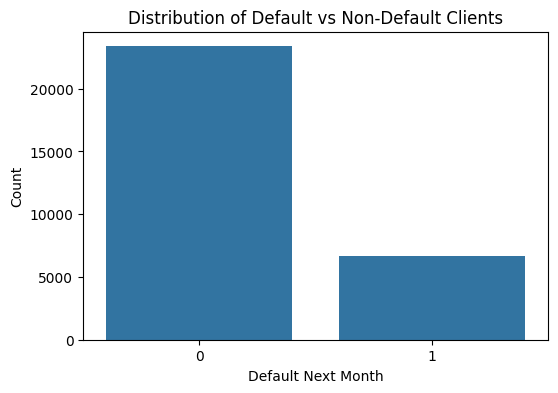

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='default.payment.next.month',
    data=df
)

plt.title("Distribution of Default vs Non-Default Clients")
plt.xlabel("Default Next Month")
plt.ylabel("Count")

plt.show()

### Class Balance Insight

The dataset is moderately imbalanced, with non-default cases significantly outnumbering default cases.

This imbalance is important because relying solely on accuracy may produce misleading model performance. Therefore, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be prioritized during modeling.

# **Data Cleaning & Quality Checks**

Before performing exploratory analysis and model development, the dataset was inspected for:
- duplicate records,
- undocumented categorical values,
- anomalous repayment codes,
- inconsistent billing values,
- and potential data quality issues.

Special attention was given to undocumented categories and unusual financial values, since these may significantly affect downstream analysis and model behavior.

Check Duplicates

In [8]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Duplicate Record Check

Duplicate records were checked to ensure that no client observations were repeated in the dataset, which could otherwise bias analysis and model training.

Rename Target Column

In [9]:
# Rename target column for convenience
df.rename(
    columns={'default.payment.next.month': 'DEFAULT'},
    inplace=True
)

Inspect Category Anomalies

In [10]:
# EDUCATION value counts
print(df['EDUCATION'].value_counts().sort_index())

# MARRIAGE value counts
print(df['MARRIAGE'].value_counts().sort_index())

# SEX value counts
print(df['SEX'].value_counts().sort_index())

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64
SEX
1    11888
2    18112
Name: count, dtype: int64


Handle Undocumented Categories

In [11]:
# Merge undocumented EDUCATION categories into 'Other'
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# Merge undocumented MARRIAGE category into 'Other'
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

### Handling Undocumented Categories

The dataset contains undocumented categorical values in the `EDUCATION` and `MARRIAGE` variables.

- `EDUCATION` contains values `0`, `5`, and `6`, which are not formally documented in the dataset description.
- `MARRIAGE` contains value `0`, which is also undocumented.

To improve interpretability and reduce category sparsity:
- `EDUCATION` values `0`, `5`, and `6` were grouped into the `Other` category (`4`)
- `MARRIAGE` value `0` was grouped into the `Other` category (`3`)

This approach preserves the observations while avoiding ambiguous standalone categories.

Convert to Categorical Types

In [12]:
# Convert encoded categorical variables to categorical dtype
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

for col in categorical_cols:
    df[col] = df[col].astype('category')

Inspect PAY Variables

In [13]:
# Repayment status columns
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_cols:
    print(f"\n{col} Value Counts:")
    print(df[col].value_counts().sort_index())


PAY_0 Value Counts:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2 Value Counts:
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3 Value Counts:
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4 Value Counts:
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5 Value Counts:
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6 Value Counts:
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184


### Repayment Status Variables

The repayment status variables (`PAY_0` to `PAY_6`) contain ordinal repayment behavior information.

According to the dataset documentation:
- `-2` → no consumption
- `-1` → paid duly
- `0` → revolving credit / no delay
- `1–9` → repayment delay in months

These variables are expected to be among the strongest predictors of default risk because they directly capture historical delinquency behavior.

Check Negative BILL_AMT Values

In [14]:
# BILL_AMT columns
bill_cols = [
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'
]

# Count negative bill amounts
negative_bill_counts = (df[bill_cols] < 0).sum()

negative_bill_counts

,0
BILL_AMT1,590
BILL_AMT2,669
BILL_AMT3,655
BILL_AMT4,675
BILL_AMT5,655
BILL_AMT6,688


### Negative Bill Amounts

Negative bill statement amounts were identified in several billing columns.

These values likely represent:
- overpayments,
- statement corrections,
- or excess credit balances.

Since negative balances may still contain meaningful financial information, they were retained rather than removed. However, their presence was documented as part of the data quality review.

Final Data Type Check

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   ID         30000 non-null  int64   
 1   LIMIT_BAL  30000 non-null  float64 
 2   SEX        30000 non-null  category
 3   EDUCATION  30000 non-null  category
 4   MARRIAGE   30000 non-null  category
 5   AGE        30000 non-null  int64   
 6   PAY_0      30000 non-null  int64   
 7   PAY_2      30000 non-null  int64   
 8   PAY_3      30000 non-null  int64   
 9   PAY_4      30000 non-null  int64   
 10  PAY_5      30000 non-null  int64   
 11  PAY_6      30000 non-null  int64   
 12  BILL_AMT1  30000 non-null  float64 
 13  BILL_AMT2  30000 non-null  float64 
 14  BILL_AMT3  30000 non-null  float64 
 15  BILL_AMT4  30000 non-null  float64 
 16  BILL_AMT5  30000 non-null  float64 
 17  BILL_AMT6  30000 non-null  float64 
 18  PAY_AMT1   30000 non-null  float64 
 19  PAY_AMT2   30000 non-null

### Data Cleaning Summary

Key preprocessing steps completed:
- Verified duplicate records
- Handled undocumented categorical values
- Converted categorical variables to appropriate data types
- Reviewed repayment status encoding
- Investigated anomalous billing values

The dataset is now prepared for exploratory data analysis and feature engineering.

# **Exploratory Data Analysis**
The purpose of this section is to understand:
- borrower demographics,
- repayment behavior,
- financial usage patterns,
- and their relationship with default risk.

The analysis focuses on identifying meaningful behavioral indicators that may help predict future defaults.

1. Univariate Analysis

A. LIMIT_BAL Distribution

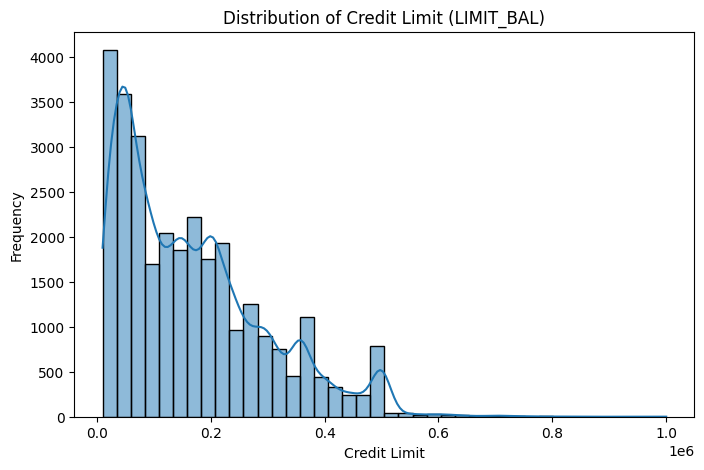

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['LIMIT_BAL'],
    bins=40,
    kde=True
)

plt.title("Distribution of Credit Limit (LIMIT_BAL)")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")

plt.show()

### Insight

The distribution of credit limits is right-skewed, with a large concentration of clients in lower-to-mid credit ranges.

A smaller number of clients possess very high credit limits, indicating potential outliers or high-value borrowers.

B. AGE Distribution

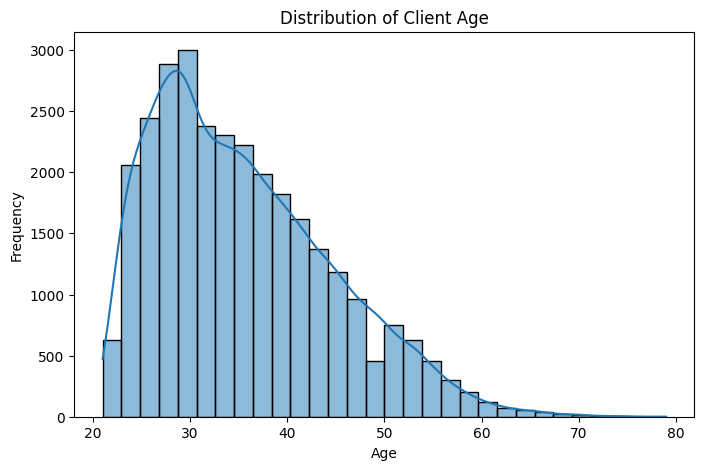

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['AGE'],
    bins=30,
    kde=True
)

plt.title("Distribution of Client Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Insight

Most clients fall within the working-age population, with a concentration between approximately 25 and 40 years.

This suggests that the dataset primarily represents economically active borrowers.

C. PAY_0 Distribution

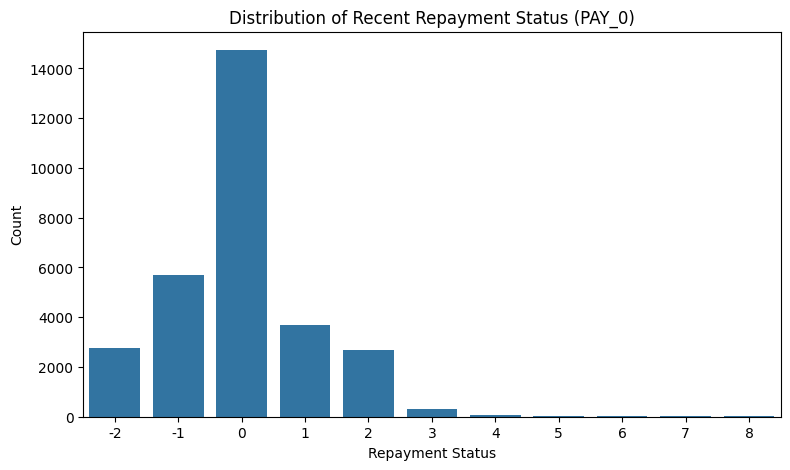

In [18]:
plt.figure(figsize=(9,5))

sns.countplot(
    x='PAY_0',
    data=df,
    order=sorted(df['PAY_0'].unique())
)

plt.title("Distribution of Recent Repayment Status (PAY_0)")
plt.xlabel("Repayment Status")
plt.ylabel("Count")

plt.show()

### Insight

Most clients fall within the non-delayed repayment categories (`-1` and `0`), indicating relatively healthy repayment behavior overall.

However, a noticeable subset of clients shows repayment delays of multiple months, which may represent elevated default risk.

2. Default Rate Across Demographics

A. Default Rate by SEX

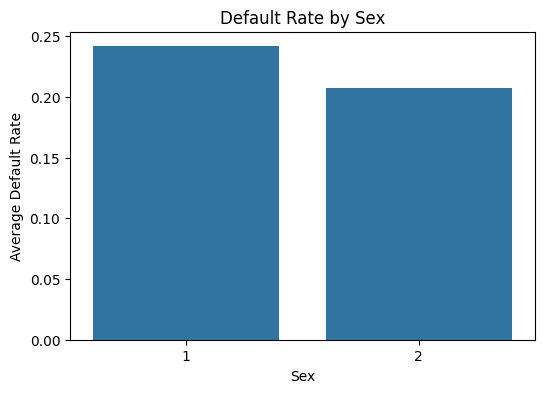

In [19]:
sex_default = (
    df.groupby('SEX')['DEFAULT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x='SEX',
    y='DEFAULT',
    data=sex_default
)

plt.title("Default Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Default Rate")

plt.show()

B. Default Rate by EDUCATION

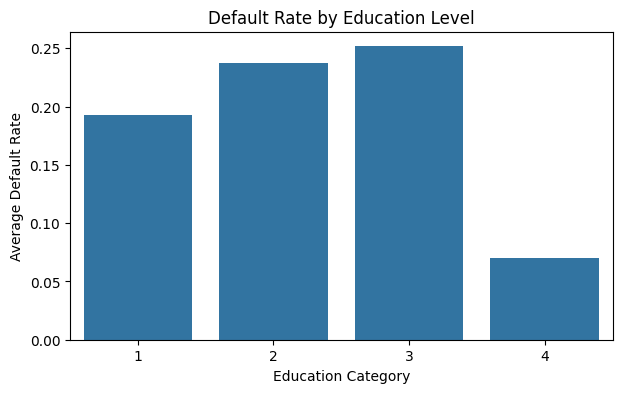

In [20]:
education_default = (
    df.groupby('EDUCATION')['DEFAULT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))

sns.barplot(
    x='EDUCATION',
    y='DEFAULT',
    data=education_default
)

plt.title("Default Rate by Education Level")
plt.xlabel("Education Category")
plt.ylabel("Average Default Rate")

plt.show()

C. AGE Bands

In [21]:
# Create age groups
df['AGE_GROUP'] = pd.cut(
    df['AGE'],
    bins=[20, 30, 40, 50, 60, 80],
    labels=['21-30', '31-40', '41-50', '51-60', '60+']
)

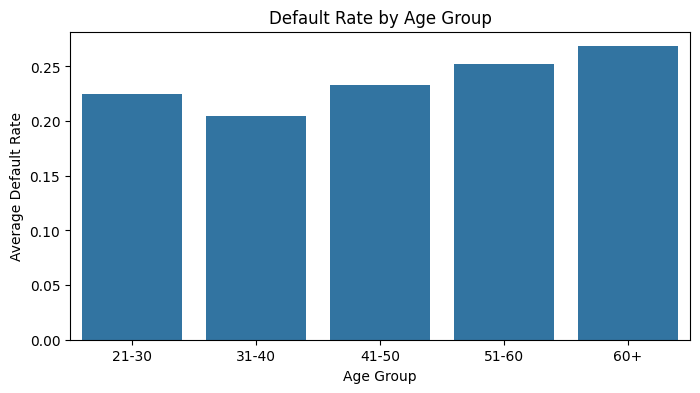

In [22]:
age_default = (
    df.groupby('AGE_GROUP')['DEFAULT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))

sns.barplot(
    x='AGE_GROUP',
    y='DEFAULT',
    data=age_default
)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Default Rate")

plt.show()

### Demographic Risk Insights

Default behavior varies across demographic groups, suggesting that repayment risk may be influenced by factors such as education level, marital status, and age.

However, demographic variables alone are unlikely to fully explain default behavior and should be interpreted alongside financial and repayment patterns.

## **3. Repayment Behavior Analysis**

Repayment history is one of the strongest indicators of future credit default.

This section analyzes how repayment delays across recent months relate to default behavior and whether repeated delinquency patterns are associated with elevated credit risk.

A. Default Rate by PAY_0

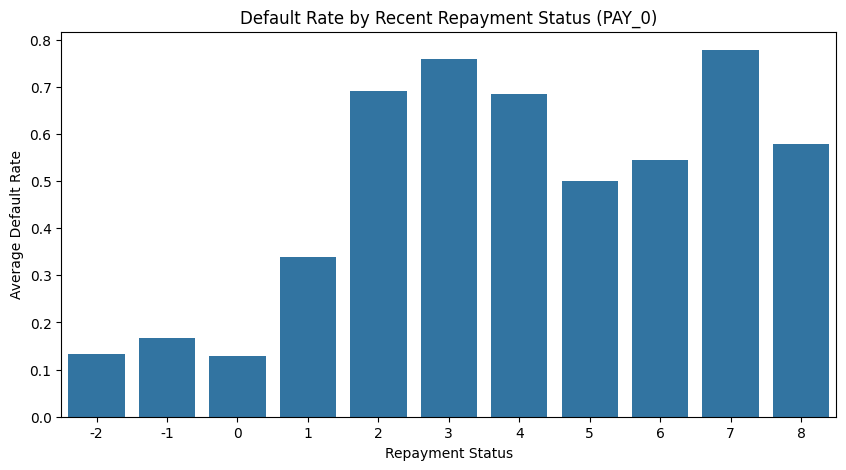

In [23]:
pay0_default = (
    df.groupby('PAY_0')['DEFAULT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='PAY_0',
    y='DEFAULT',
    data=pay0_default,
    order=sorted(df['PAY_0'].unique())
)

plt.title("Default Rate by Recent Repayment Status (PAY_0)")
plt.xlabel("Repayment Status")
plt.ylabel("Average Default Rate")

plt.show()

### Insight

Default rates increase sharply as repayment delays become more severe.

Clients with recent repayment delays of multiple months exhibit significantly higher default probabilities compared to clients who paid on time or had no consumption activity.

This suggests that recent delinquency behavior is a critical leading indicator of credit risk.

B. Multi-Month Delay Analysis

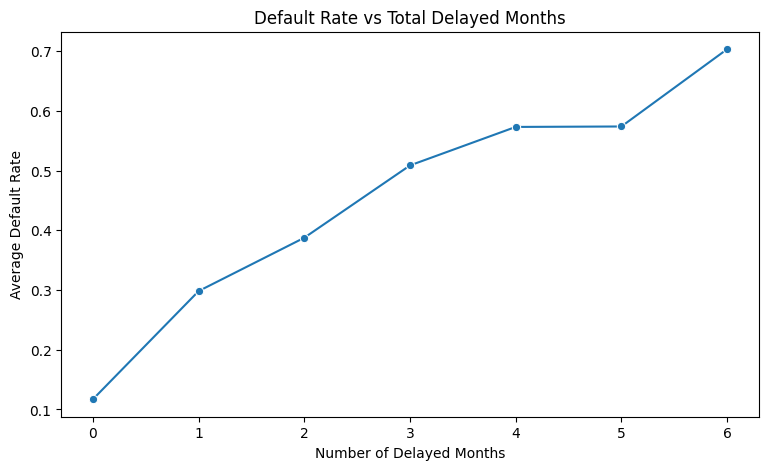

In [24]:
# Repayment status columns
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Count months with repayment delay
df['TOTAL_DELAY_MONTHS'] = (df[pay_cols] > 0).sum(axis=1)

delay_default = (
    df.groupby('TOTAL_DELAY_MONTHS')['DEFAULT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9,5))

sns.lineplot(
    x='TOTAL_DELAY_MONTHS',
    y='DEFAULT',
    data=delay_default,
    marker='o'
)

plt.title("Default Rate vs Total Delayed Months")
plt.xlabel("Number of Delayed Months")
plt.ylabel("Average Default Rate")

plt.show()

### Insight

Clients with repeated repayment delays across multiple months show progressively higher default rates.

This indicates that cumulative delinquency behavior is strongly associated with elevated repayment risk and may serve as an important predictive feature for classification models.

C. Heatmap of Repayment Delays by Default Status

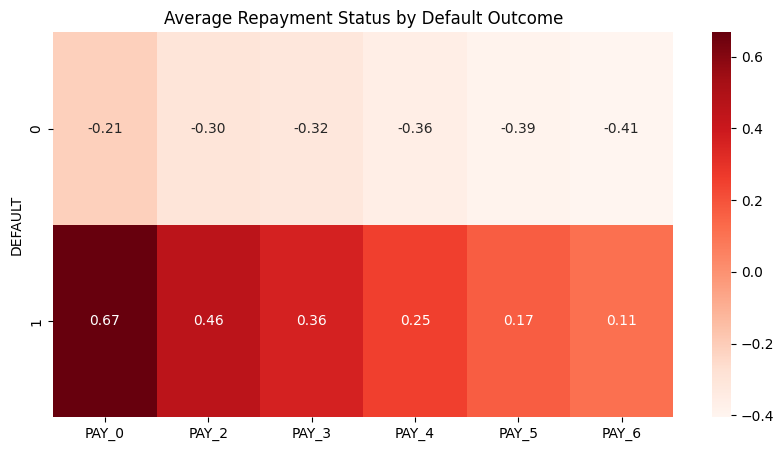

In [25]:
repayment_pattern = (
    df.groupby('DEFAULT')[pay_cols]
    .mean()
)

plt.figure(figsize=(10,5))

sns.heatmap(
    repayment_pattern,
    annot=True,
    cmap='Reds',
    fmt='.2f'
)

plt.title("Average Repayment Status by Default Outcome")

plt.show()

### Insight

Defaulting clients consistently exhibit higher repayment delay values across all observed months.

The pattern suggests that repayment stress is persistent rather than isolated to a single billing cycle, reinforcing the importance of historical delinquency behavior in credit risk assessment.

D. Additional Smart Feature — MAX_DELAY

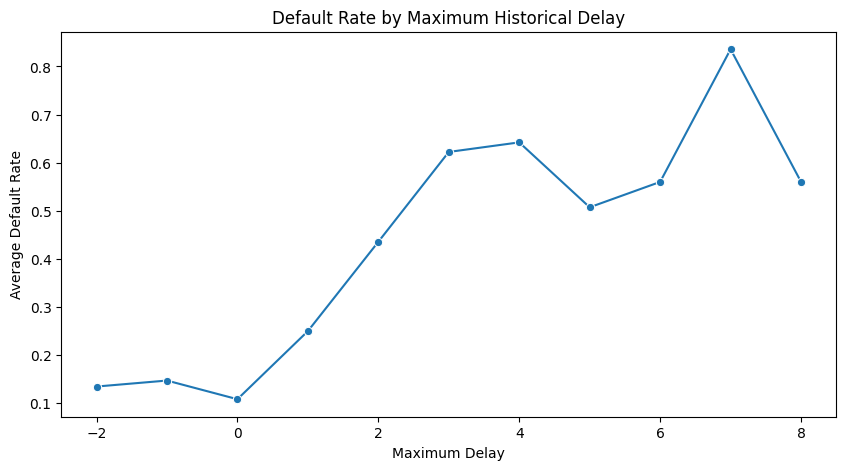

In [26]:
# Maximum repayment delay observed across months
df['MAX_DELAY'] = df[pay_cols].max(axis=1)

max_delay_default = (
    df.groupby('MAX_DELAY')['DEFAULT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x='MAX_DELAY',
    y='DEFAULT',
    data=max_delay_default,
    marker='o'
)

plt.title("Default Rate by Maximum Historical Delay")
plt.xlabel("Maximum Delay")
plt.ylabel("Average Default Rate")

plt.show()

### Insight

Even a single severe repayment delay appears strongly associated with increased default risk.

This suggests that extreme delinquency events may serve as strong warning signals for future repayment failure.

## 4. Financial Behavior Analysis

Beyond repayment delays, borrower financial behavior also provides important signals about default risk.

This section analyzes:
- credit utilization patterns,
- billing behavior,
- and repayment consistency

to understand how financial stress and payment habits relate to future default outcomes.

A. Credit Limit vs Default

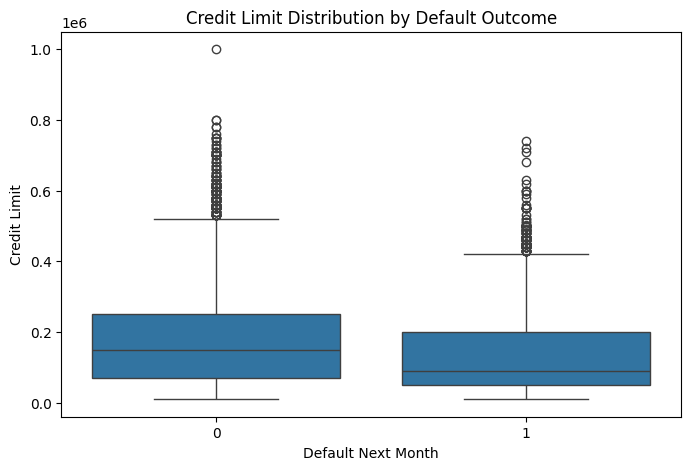

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='DEFAULT',
    y='LIMIT_BAL',
    data=df
)

plt.title("Credit Limit Distribution by Default Outcome")
plt.xlabel("Default Next Month")
plt.ylabel("Credit Limit")

plt.show()

### Insight

Clients who default tend to have lower median credit limits compared to non-defaulting clients.

This may indicate that lower credit capacity borrowers are more financially vulnerable or have weaker repayment profiles.

B. Feature Engineering — AVG_UTIL_RATE

In [28]:
# Bill amount columns
bill_cols = [
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'
]

# Credit utilization across months
util_matrix = df[bill_cols].div(df['LIMIT_BAL'], axis=0)

# Average utilization rate
df['AVG_UTIL_RATE'] = util_matrix.mean(axis=1)

### Feature: AVG_UTIL_RATE

`AVG_UTIL_RATE` measures the average proportion of a client's available credit that is being utilized across six months.

Higher utilization may indicate:
- financial stress,
- dependence on revolving credit,
- or reduced repayment flexibility.

Therefore, elevated utilization rates are expected to correlate with increased default risk.

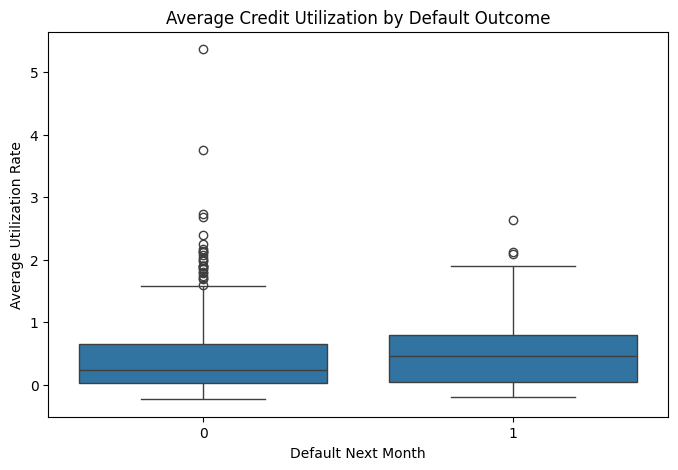

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='DEFAULT',
    y='AVG_UTIL_RATE',
    data=df
)

plt.title("Average Credit Utilization by Default Outcome")
plt.xlabel("Default Next Month")
plt.ylabel("Average Utilization Rate")

plt.show()

### Insight

Defaulting clients generally exhibit higher credit utilization rates, suggesting heavier dependence on available credit and increased financial pressure.

C. Feature Engineering — AVG_PAY_RATIO

In [30]:
# Payment amount columns
pay_amt_cols = [
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

# Calculate repayment ratios safely
pay_ratio_matrix = []

for bill_col, pay_col in zip(bill_cols, pay_amt_cols):

    ratio = np.where(
        df[bill_col] > 0,
        df[pay_col] / df[bill_col],
        np.nan
    )

    pay_ratio_matrix.append(ratio)

# Convert to dataframe
pay_ratio_matrix = pd.DataFrame(pay_ratio_matrix).T

# Average repayment ratio
df['AVG_PAY_RATIO'] = pay_ratio_matrix.mean(axis=1)

In [31]:
# Handle NaN values in repayment ratio
df['AVG_PAY_RATIO'] = df['AVG_PAY_RATIO'].fillna(0)

### Feature: AVG_PAY_RATIO

`AVG_PAY_RATIO` measures how consistently a client repays their billed amount across multiple months.

Higher repayment ratios suggest:
- stronger repayment discipline,
- healthier financial behavior,
- and lower repayment stress.

Clients with persistently low repayment ratios may be at greater risk of future default.

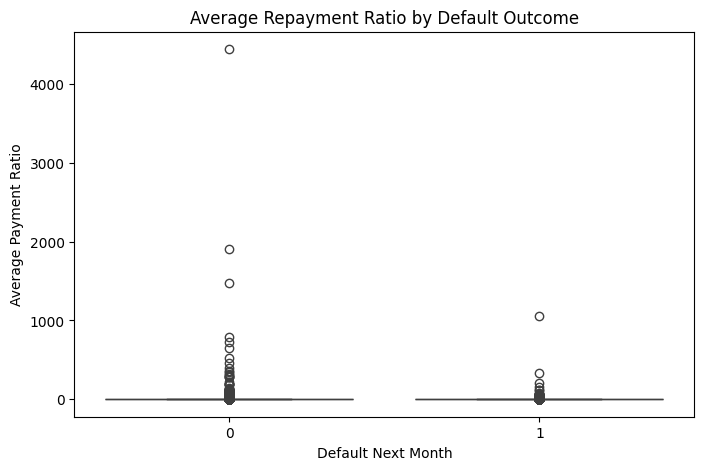

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='DEFAULT',
    y='AVG_PAY_RATIO',
    data=df
)

plt.title("Average Repayment Ratio by Default Outcome")
plt.xlabel("Default Next Month")
plt.ylabel("Average Payment Ratio")

plt.show()

### Insight

Non-defaulting clients generally demonstrate stronger repayment consistency, while defaulting clients tend to repay a smaller proportion of their outstanding bills.

D. Correlation Between Engineered Features and Default

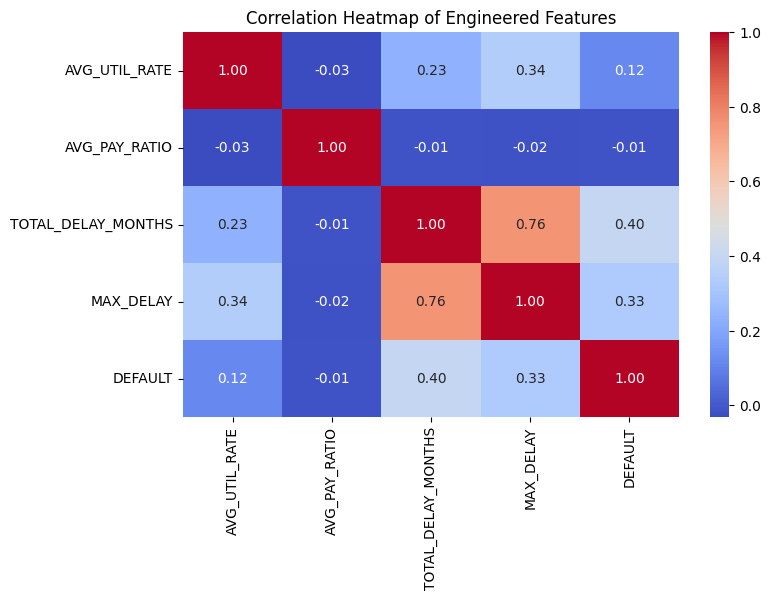

In [33]:
engineered_features = [
    'AVG_UTIL_RATE',
    'AVG_PAY_RATIO',
    'TOTAL_DELAY_MONTHS',
    'MAX_DELAY',
    'DEFAULT'
]

corr_matrix = df[engineered_features].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Engineered Features")

plt.show()

### Insight

Repayment delay features show strong positive relationships with default risk, while repayment consistency features exhibit negative relationships.

This reinforces the importance of behavioral repayment history in predicting future delinquency.

## 5 Correlation Analysis & Key Predictors

To better understand relationships between variables, a correlation analysis was performed on key financial, repayment, and engineered features.

The objective is to identify variables that show strong associations with default behavior and may contribute significantly to predictive modeling.

A. Full Correlation Heatmap

In [34]:
corr_features = [
    'LIMIT_BAL',
    'AGE',
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6',
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'AVG_UTIL_RATE',
    'AVG_PAY_RATIO',
    'TOTAL_DELAY_MONTHS',
    'MAX_DELAY',
    'DEFAULT'
]

corr_matrix = df[corr_features].corr()

Plot Heatmap

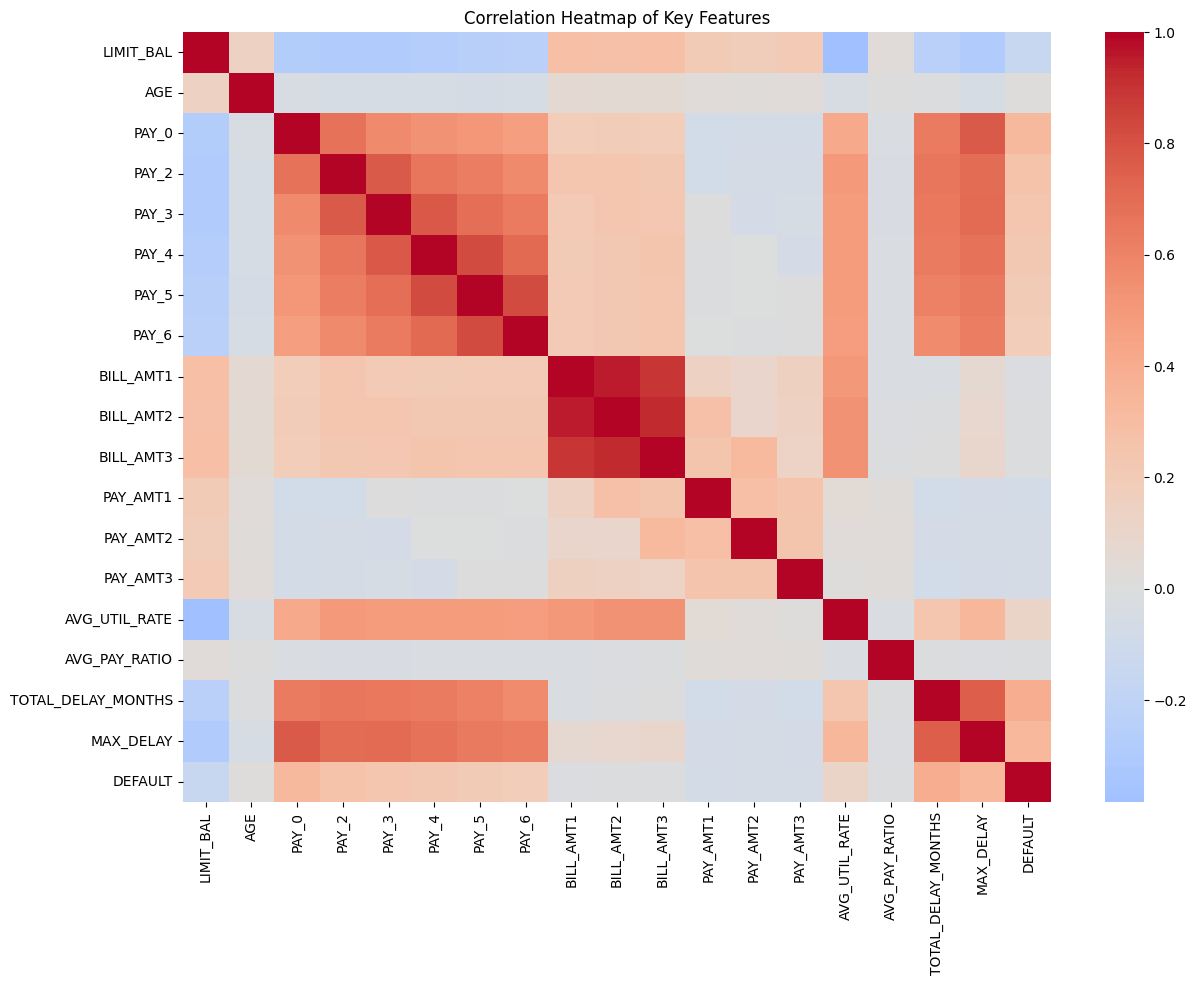

In [35]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap of Key Features")

plt.show()

### Insight

Repayment delay variables (`PAY_x`) and engineered delinquency features exhibit the strongest positive relationships with default risk.

Payment amount variables generally show weaker negative relationships, suggesting that repayment behavior may be more informative than raw transaction magnitude alone.

B. Top Features Correlated With Default

Compute Correlations

In [36]:
# Correlation with target
default_corr = (
    corr_matrix['DEFAULT']
    .drop('DEFAULT')
    .sort_values(key=abs, ascending=False)
)

# Top 10 correlations
top_corr = default_corr.head(10)

top_corr

,DEFAULT
TOTAL_DELAY_MONTHS,0.398394
MAX_DELAY,0.331036
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
LIMIT_BAL,-0.153520
AVG_UTIL_RATE,0.115483


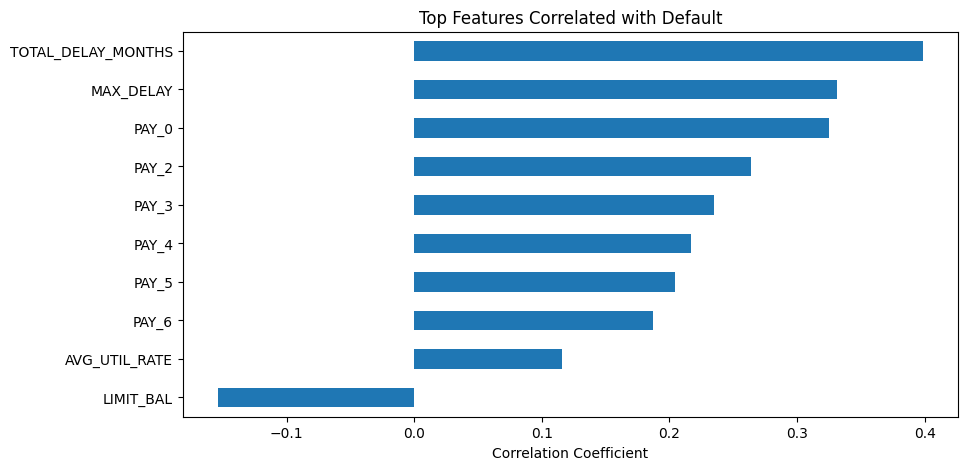

In [37]:
plt.figure(figsize=(10,5))

top_corr.sort_values().plot(kind='barh')

plt.title("Top Features Correlated with Default")
plt.xlabel("Correlation Coefficient")

plt.show()

### Key Predictive Signals

The strongest predictors of default are primarily related to repayment behavior and delinquency history.

Features such as:
- recent repayment delays,
- cumulative delayed months,
- and maximum historical delay

show substantially stronger relationships with default compared to demographic attributes.

This suggests that behavioral repayment patterns are more informative indicators of credit risk than static demographic variables.

## EDA Summary

Key findings from exploratory analysis:

- Repayment delay variables are the strongest indicators of future default risk.
- Clients with repeated or severe delinquency histories exhibit substantially higher default rates.
- Higher credit utilization is associated with increased financial stress and elevated default probability.
- Strong repayment consistency appears correlated with lower default risk.
- Demographic variables show weaker predictive relationships compared to behavioral financial variables.

These findings suggest that repayment behavior and financial discipline are likely to play central roles in predictive modeling.

# **Feature Engineering & Preprocessing**

Based on the exploratory analysis, additional behavioral risk features were engineered to better capture:
- repayment consistency,
- credit utilization patterns,
- and cumulative delinquency behavior.

The dataset was then prepared for machine learning by:
- selecting predictive features,
- encoding categorical variables,
- handling class imbalance considerations,
- and splitting the data into training and testing sets.

In [38]:
engineered_cols = [
    'AVG_UTIL_RATE',
    'AVG_PAY_RATIO',
    'TOTAL_DELAY_MONTHS',
    'MAX_DELAY'
]

df[engineered_cols].head()

,AVG_UTIL_RATE,AVG_PAY_RATIO,TOTAL_DELAY_MONTHS,MAX_DELAY
0,0.064200,0.074038,2,2
1,0.023718,0.311916,2,2
2,0.188246,0.115141,0,0
3,0.771113,0.036396,0,0
4,0.364463,1.246958,0,0


Define Features & Target

In [39]:
# Drop non-predictive columns
drop_cols = ['ID', 'DEFAULT', 'AGE_GROUP']

X = df.drop(columns=drop_cols)

# Target
y = df['DEFAULT']

Identify Categorical Columns

In [40]:
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

# One-hot encoding
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

### Encoding Strategy

Categorical variables were one-hot encoded to convert them into machine-readable numerical representations.

`drop_first=True` was used to reduce multicollinearity and avoid redundant dummy variables.

Train-Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Train-Test Split

A stratified train-test split was used to preserve the original class distribution across both training and testing datasets.

This is particularly important for imbalanced classification problems such as credit default prediction.

Feature Scaling

Numeric Columns

In [42]:
# Initialize scaler
scaler = StandardScaler()

# Scale features for Logistic Regression
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling was applied before Logistic Regression to standardize variable magnitudes and improve optimization stability.

Tree-based models are less sensitive to feature scaling and therefore do not strictly require normalization.

### Handling Class Imbalance

The dataset contains a moderate class imbalance, with default cases representing a minority of observations.

To address this issue:
- `class_weight='balanced'` will be used during model training.

This approach was preferred over synthetic oversampling techniques such as SMOTE because:
- it preserves the original data distribution,
- avoids introducing artificial observations,
- and provides a simpler, more interpretable baseline for financial risk modeling.

Final Shape Check

In [43]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (24000, 30)
Testing Shape: (6000, 30)


The dataset is now fully prepared for predictive modeling.

The next section compares:
1. an interpretable Logistic Regression baseline,
2. and a tree-based ensemble model

to evaluate their ability to predict future credit defaults.

## Logistic Regression Baseline

Logistic Regression was selected as the baseline model because:
- it is interpretable,
- computationally efficient,
- and widely used in credit-risk modeling.

As a linear classification model, it provides a strong benchmark for understanding how predictive signals relate to default probability.

Train Logistic Regression

In [44]:
# Initialize Logistic Regression model
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42

)

# Train model
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [45]:
# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Prediction probabilities
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [46]:
# Evaluation metrics
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance:\n")

print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {auc_lr:.4f}")

Logistic Regression Performance:

Precision : 0.4406
Recall    : 0.6014
F1 Score  : 0.5086
ROC-AUC   : 0.7470


In [47]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.78      0.83      4673
           1       0.44      0.60      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.74      0.76      6000



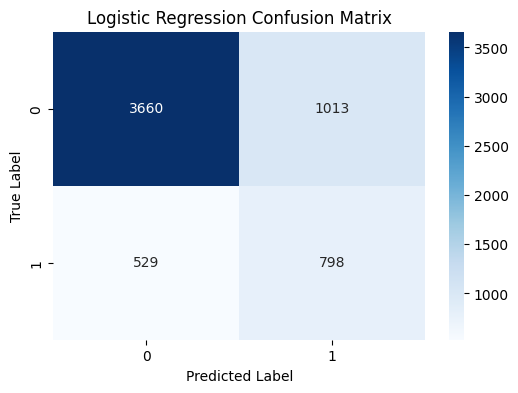

In [48]:
# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

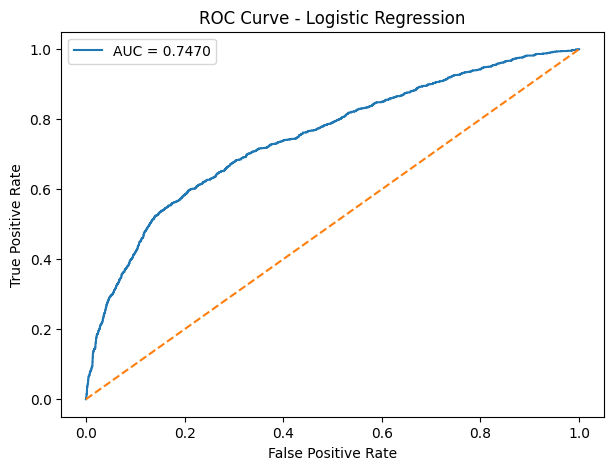

In [49]:
# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7,5))

plt.plot(fpr_lr, tpr_lr, label=f"AUC = {auc_lr:.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

Cross Validation

In [50]:
# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation ROC-AUC
cv_scores_lr = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='roc_auc'
)

print("Logistic Regression CV ROC-AUC Scores:\n")
print(cv_scores_lr)

print(f"\nMean ROC-AUC: {cv_scores_lr.mean():.4f}")
print(f"Std ROC-AUC : {cv_scores_lr.std():.4f}")

Logistic Regression CV ROC-AUC Scores:

[0.76764415 0.76369379 0.75053882 0.75393803 0.76530346]

Mean ROC-AUC: 0.7602
Std ROC-AUC : 0.0067


### Logistic Regression Insights

The Logistic Regression model provides a strong and interpretable baseline for default prediction.

The model demonstrates reasonable discrimination ability, indicating that repayment behavior and financial usage patterns contain meaningful predictive signals for identifying high-risk borrowers.

Because Logistic Regression is inherently interpretable, it also serves as a useful benchmark for understanding how individual variables contribute to default probability.

Feature Coffecients

In [51]:
# Logistic Regression coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})

# Absolute importance
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Top features
top_coef = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(10)

top_coef

,Feature,Coefficient,Abs_Coefficient
20,TOTAL_DELAY_MONTHS,0.835948,0.835948
21,MAX_DELAY,0.305114,0.305114
0,LIMIT_BAL,-0.217057,0.217057
2,PAY_0,0.162240,0.162240
7,PAY_6,-0.144617,0.144617
14,PAY_AMT1,-0.144003,0.144003
4,PAY_3,-0.137354,0.137354
3,PAY_2,-0.135917,0.135917
9,BILL_AMT2,0.134381,0.134381
15,PAY_AMT2,-0.130019,0.130019


Visualize

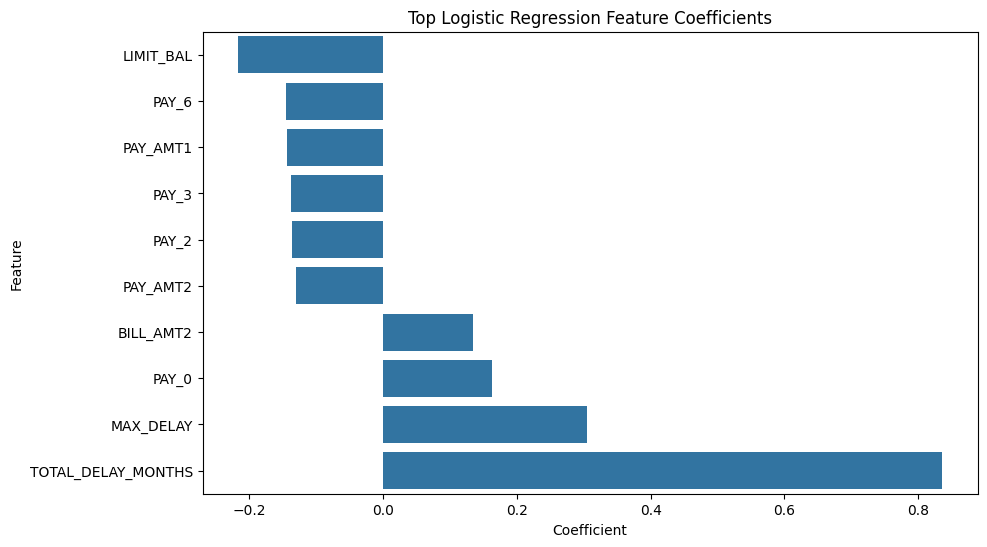

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_coef.sort_values(by='Coefficient')
)

plt.title("Top Logistic Regression Feature Coefficients")

plt.show()

### Coefficient Interpretation

Repayment delay variables and engineered delinquency features contribute most strongly to predicted default probability.

This reinforces earlier exploratory findings that historical repayment behavior is a primary driver of credit risk.

# Tree-Based Model — Random Forest

To capture nonlinear relationships and feature interactions, a Random Forest classifier was trained alongside the Logistic Regression baseline.

Random Forest models are particularly useful in credit-risk prediction because they:
- handle complex behavioral patterns,
- are robust to noise and outliers,
- and provide feature importance estimates for interpretability.

Train Model

In [53]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=5,
                       min_samples_split=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [54]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

# Prediction probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [55]:
# Evaluation metrics
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance:\n")

print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {auc_rf:.4f}"
)

Random Forest Performance:

Precision : 0.4752
Recall    : 0.6127
F1 Score  : 0.5352
ROC-AUC   : 0.7750


In [56]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.48      0.61      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



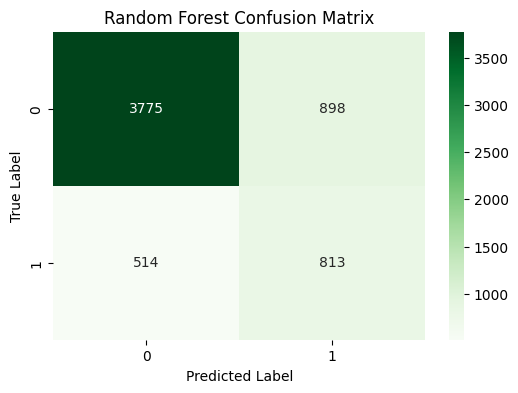

In [57]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

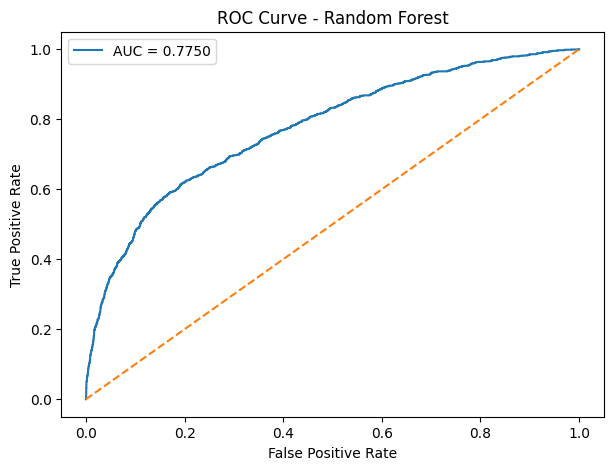

In [58]:
# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [59]:
# Cross-validation ROC-AUC
cv_scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc'
)

print("Random Forest CV ROC-AUC Scores:\n")
print(cv_scores_rf)

print(f"\nMean ROC-AUC: {cv_scores_rf.mean():.4f}")
print(f"Std ROC-AUC : {cv_scores_rf.std():.4f}")

Random Forest CV ROC-AUC Scores:

[0.7867567  0.78394919 0.77447972 0.7886224  0.7862623 ]

Mean ROC-AUC: 0.7840
Std ROC-AUC : 0.0050


Model Comparison

In [60]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf],
    'F1 Score': [f1_lr, f1_rf],
    'ROC-AUC': [auc_lr, auc_rf]
})

comparison_df

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.440641,0.601356,0.508604,0.746985
1,Random Forest,0.475161,0.612660,0.535221,0.775039


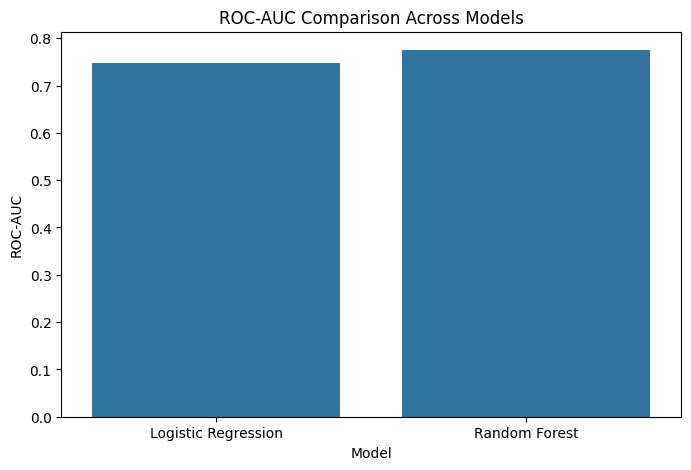

In [61]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='ROC-AUC',
    data=comparison_df
)

plt.title("ROC-AUC Comparison Across Models")

plt.show()

### Model Comparison Insights

The Random Forest model demonstrates stronger predictive performance compared to the Logistic Regression baseline, particularly in capturing complex repayment behavior patterns.

This improvement suggests that nonlinear relationships and feature interactions play an important role in credit default prediction.

However, Logistic Regression remains valuable due to its interpretability and transparency in financial decision-making contexts.

Feature Importance

In [62]:
# Feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 features
top_features = feature_importance.head(10)

top_features

,Feature,Importance
21,MAX_DELAY,0.172413
2,PAY_0,0.162216
20,TOTAL_DELAY_MONTHS,0.121888
3,PAY_2,0.081506
4,PAY_3,0.042676
22,AVG_UTIL_RATE,0.036511
5,PAY_4,0.031652
0,LIMIT_BAL,0.030735
15,PAY_AMT2,0.026981
14,PAY_AMT1,0.026344


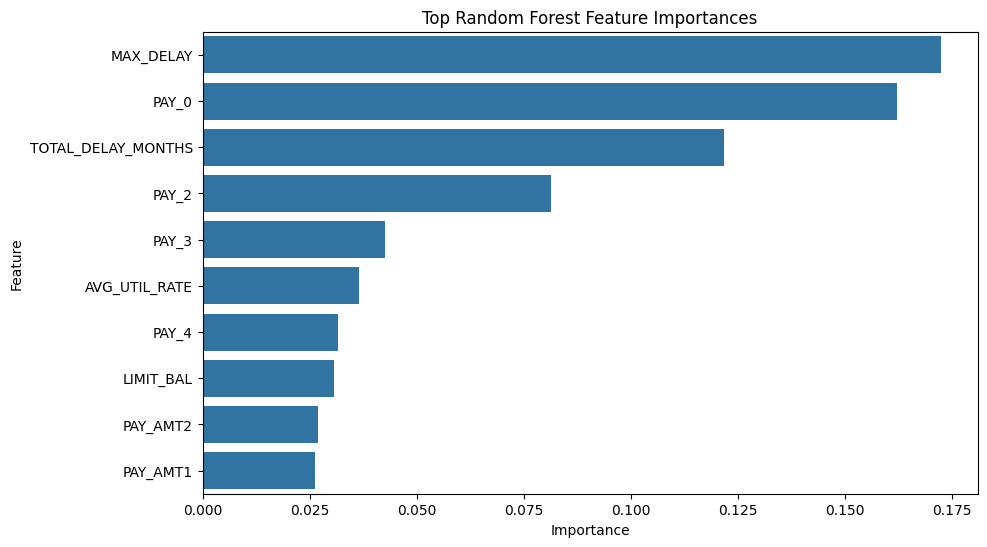

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Random Forest Feature Importances")

plt.show()

### Feature Importance Insights

Repayment delay features dominate model importance rankings, reinforcing the conclusion that historical delinquency behavior is the strongest indicator of future default risk.

Engineered behavioral features such as:
- cumulative delayed months,
- repayment consistency,
- and credit utilization

also contribute meaningfully to predictive performance.

# Model Explainability with SHAP

In financial risk modeling, explainability is critical because lending decisions directly affect customers and business outcomes.

To better understand how the Random Forest model makes predictions, SHAP (SHapley Additive exPlanations) was used to analyze feature contributions and identify the variables most responsible for predicted default risk.

In [64]:
!pip install shap -q

In [65]:
import shap

In [66]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

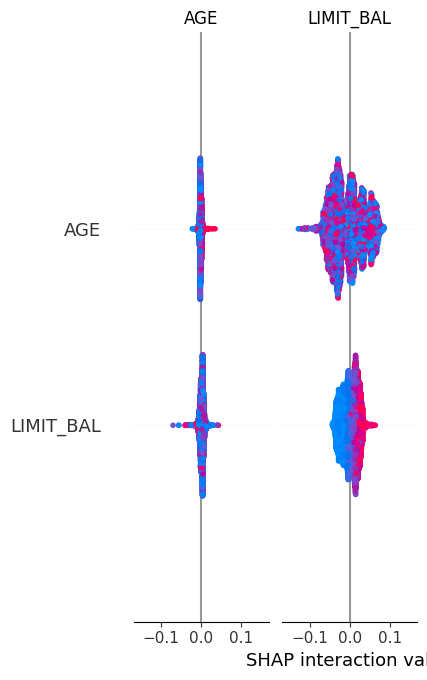

In [69]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test
)

### SHAP Summary Insights

The SHAP summary plot highlights the features contributing most strongly to predicted default risk across the dataset.

Repayment delay variables and delinquency-related engineered features consistently exert the strongest influence on model predictions, reinforcing findings from both exploratory analysis and feature importance rankings.

# Fairness Analysis

In lending systems, predictive fairness is important because model errors can disproportionately affect specific demographic groups.

To perform a basic fairness assessment, False Positive Rates (FPR) were compared across selected demographic categories.

A high False Positive Rate means that low-risk clients are incorrectly classified as likely defaulters, which could negatively affect credit access.

In [72]:
from sklearn.metrics import confusion_matrix

def calculate_fpr(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return fp / (fp + tn)

In [73]:
# Create evaluation dataframe
fairness_df = X_test.copy()

fairness_df['TRUE_LABEL'] = y_test.values
fairness_df['PRED_LABEL'] = y_pred_rf

# Add demographic columns from original dataset
fairness_df['SEX'] = df.loc[X_test.index, 'SEX'].values
fairness_df['EDUCATION'] = df.loc[X_test.index, 'EDUCATION'].values

In [74]:
# False Positive Rate by SEX
sex_fpr = {}

for group in fairness_df['SEX'].unique():

    subset = fairness_df[fairness_df['SEX'] == group]

    fpr = calculate_fpr(
        subset['TRUE_LABEL'],
        subset['PRED_LABEL']
    )

    sex_fpr[group] = fpr

sex_fpr

{1: np.float64(0.2042368278109723), 2: np.float64(0.1843220338983051)}

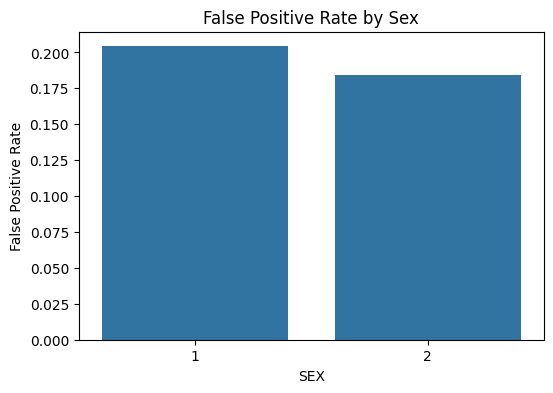

In [75]:
sex_fpr_df = pd.DataFrame({
    'SEX': sex_fpr.keys(),
    'False Positive Rate': sex_fpr.values()
})

plt.figure(figsize=(6,4))

sns.barplot(
    x='SEX',
    y='False Positive Rate',
    data=sex_fpr_df
)

plt.title("False Positive Rate by Sex")

plt.show()

In [76]:
# False Positive Rate by EDUCATION
edu_fpr = {}

for group in fairness_df['EDUCATION'].unique():

    subset = fairness_df[fairness_df['EDUCATION'] == group]

    fpr = calculate_fpr(
        subset['TRUE_LABEL'],
        subset['PRED_LABEL']
    )

    edu_fpr[group] = fpr

edu_fpr

{2: np.float64(0.2129367327667611),
 1: np.float64(0.15710144927536232),
 3: np.float64(0.22576361221779548),
 4: np.float64(0.07792207792207792)}

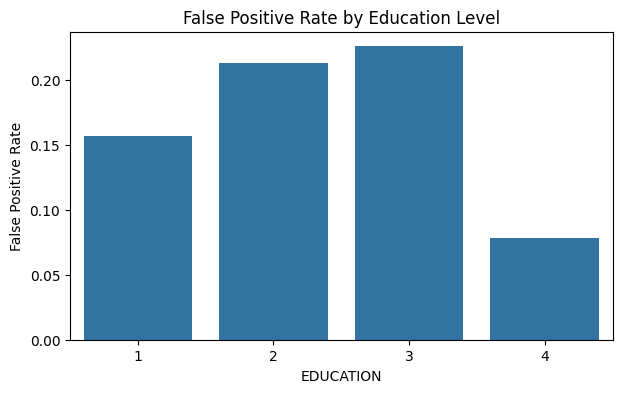

In [77]:
edu_fpr_df = pd.DataFrame({
    'EDUCATION': edu_fpr.keys(),
    'False Positive Rate': edu_fpr.values()
})

plt.figure(figsize=(7,4))

sns.barplot(
    x='EDUCATION',
    y='False Positive Rate',
    data=edu_fpr_df
)

plt.title("False Positive Rate by Education Level")

plt.show()

### Fairness Insights

Some variation in False Positive Rates is observed across demographic groups.

However, these differences should be interpreted cautiously because:
- the analysis is exploratory,
- group sizes may vary,
- and fairness assessment requires broader statistical and regulatory evaluation.

Nevertheless, monitoring fairness metrics remains important in lending systems to reduce the risk of unintended demographic bias.

The analysis so far demonstrates that repayment behavior, delinquency history, and financial usage patterns provide strong predictive signals for identifying default risk.

The final section summarizes the business implications of these findings and outlines practical actions that a lending team could take.

# Business Summary

The analysis identified repayment behavior as the strongest indicator of future credit default risk.

Clients with repeated repayment delays, high credit utilization, and inconsistent repayment patterns were significantly more likely to default on future payments. In contrast, demographic variables such as age, sex, and marital status showed comparatively weaker predictive relationships.

Both Logistic Regression and Random Forest models demonstrated the ability to distinguish between low-risk and high-risk borrowers, with the Random Forest model achieving stronger predictive performance by capturing more complex behavioral patterns.

Feature importance analysis consistently highlighted:
- recent repayment delays,
- cumulative delinquency history,
- and repayment consistency

as the most influential predictors of default risk.

These findings suggest that borrower behavior is more informative than static demographic characteristics when assessing repayment reliability.

From a business perspective, the results indicate that digital lenders can improve risk management by closely monitoring repayment behavior trends and early warning signs of financial stress.

# Recommendations for the Credit Team

### 1. Implement Early Delinquency Monitoring

Clients showing repeated repayment delays or increasing delinquency trends should be flagged early for proactive intervention.

Potential actions may include:
- repayment reminders,
- credit counseling,
- temporary spending restrictions,
- or adjusted repayment plans.

Early intervention could help reduce future default rates and minimize financial losses.

---

### 2. Incorporate Behavioral Risk Features into Lending Decisions

Behavioral indicators such as:
- cumulative delayed months,
- repayment consistency,
- and credit utilization

should be integrated into credit scoring systems alongside traditional demographic information.

These features provide stronger predictive signals and may improve the accuracy of borrower risk assessment.

# Final Conclusion

This project demonstrated how borrower repayment behavior, financial utilization patterns, and engineered delinquency features can be used to predict credit default risk in a digital lending environment.

Through exploratory analysis, feature engineering, predictive modeling, and explainability analysis, the study showed that repayment history is the most powerful indicator of future default behavior.

The Random Forest model achieved stronger predictive performance than the Logistic Regression baseline, while SHAP analysis provided additional transparency into model decision-making.

Overall, the project highlights how data-driven credit-risk systems can support more informed lending decisions, improve early risk detection, and enhance portfolio management for digital financial institutions.

# Limitations & Future Improvements

While the models demonstrate strong predictive capability, several limitations remain:

- The dataset represents historical data from a specific region and time period (Taiwan, 2005), which may limit generalizability.
- Additional behavioral, transactional, or macroeconomic variables could further improve predictive performance.
- More advanced techniques such as XGBoost, calibrated probability estimation, or temporal sequence modeling could be explored in future iterations.
- Fairness analysis performed in this study is preliminary and should be expanded for real-world deployment scenarios.

Future work could also include:
- real-time risk scoring pipelines,
- automated monitoring systems,
- and deployment through interactive applications such as Streamlit dashboards.